# House Prices (Ames) — Pré-processamento, Modelagem e Pipeline

Continuação da análise exploratória. Contém o pipeline completo de
pré-processamento, comparativo de 5 algoritmos com validação cruzada K-Fold,
otimização de hiperparâmetros e geração do modelo final.

---

### Estrutura deste notebook

7. Preparação de `X`/`y` + `train_test_split` — fluxo correto de treino e teste  
8. `ColumnTransformer` — 4 sub-pipelines paralelos (ordinal, nominal, zero-num, contínuo)  
   8.1. Comparativo antes × depois do tratamento (tabela e gráficos)  
9. `TransformedTargetRegressor` (log1p/expm1) + validação cruzada K-Fold no `X_train`  
10. Comparativo de 5 modelos: Regressão Linear, KNN, SVR, Random Forest, Gradient Boosting  
11. Otimização do SVR via `RandomizedSearchCV`  
12. Avaliação honesta: `search.best_estimator_` aplicado no `X_test`  
13. Refit em 100% dos dados + exportação do `modelo_baseline.joblib`  
14. Validação do `pipeline.py` (CSV → predições)  
15. Conclusões

## Imports e configuracao

> **Rode esta celula primeiro.** Todos os imports do notebook estao aqui.

In [5]:
# === Manipulacao e visualizacao ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# === Modelagem (sklearn) ===
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.model_selection import (
    train_test_split, KFold, cross_validate, RandomizedSearchCV,
)
from sklearn.metrics import (
    mean_squared_log_error, mean_absolute_error, r2_score, make_scorer,
)

# === Utilidades ===
import time, joblib, os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
RNG = 42  # seed fixa para reprodutibilidade

print('Imports OK.')

Imports OK.


In [6]:
df = pd.read_csv('treino.csv')
print(f'Shape: {df.shape}')
display(df.head())

Shape: (1168, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


---
# PARTE 2 - Acompanhamento 2: Modelagem, Validacao e Pipeline

Conteudo apresentado no **segundo check-in**:
- Estrutura do `pipeline.py` rodando.
- **5 algoritmos** comparados por Validacao Cruzada K-Fold.
- Otimizacao de hiperparametros do melhor modelo.
- Geracao do `modelo_baseline.joblib` final.

### Mapa: aula -> o que sera aplicado aqui

| Aula | Conceito | Aplicacao no projeto |
|---|---|---|
| Gradiente Descendente | Feature scaling, funcao convexa, log no alvo | `StandardScaler` + `log1p(SalePrice)` |
| Validacao Cruzada | K-Fold, evitar data leakage | `KFold(5)` + tudo dentro do `Pipeline` |
| Metricas | RMSLE, MAE, R2 | `scoring` customizado |
| KNN | Baseado em distancia -> exige escalonamento | `KNeighborsRegressor` + `StandardScaler` |
| SVM | Margem maxima, Kernel Trick (RBF), `C` e `gamma` | `SVR(kernel='rbf')` + tuning |
| Ensemble - Bagging | Paralelo, reduz variancia | `RandomForestRegressor` |
| Ensemble - Boosting | Sequencial, reduz vies | `GradientBoostingRegressor` |

## 7) Preparação X / y + divisão em treino e teste

**Correção do professor:** a CV e o `RandomizedSearchCV` devem rodar **apenas sobre o conjunto de treino**, não sobre o dataset inteiro. Depois, usamos `search.best_estimator_` para prever sobre o conjunto de teste reservado e comparar `y_previsto` vs `y_real` — esse é o estimador honesto da generalização.

### Fluxo correto (aplicado abaixo):

```
treino.csv (1168 linhas)
   └─→ train_test_split(80/20, seed=42)
        ├─ X_train, y_train (≈934 linhas)  → CV + RandomizedSearchCV
        └─ X_test,  y_test  (≈234 linhas)  → avaliação final com best_estimator_
```

### Decisões de tratamento (codificadas nos grupos abaixo)

- **Colunas com >80% nulos** (`PoolQC`, `MiscFeature`, `Alley`, `Fence`) → tratadas como ordinais com `'None'`.
- **NaN como categoria válida** (`GarageType`, `BsmtQual`, `FireplaceQu`...) → preenche com `'None'`.
- **NaN como zero** (áreas/contagens de garagens e porões inexistentes) → preenche com `0`.
- **NaN aleatório** → mediana (numéricas) ou constante `'missing'` (categóricas).
- **`MSSubClass`** → tratado como string (é código de categoria, não número).

In [16]:
X = df.drop(columns=['Id', 'SalePrice']).copy()
y = df['SalePrice'].copy()
X['MSSubClass'] = X['MSSubClass'].astype(str)

# === Split treino/teste - CORRECAO DO PROFESSOR ===
# A CV e o search rodam SOMENTE sobre X_train/y_train.
# X_test/y_test ficam reservados para a avaliacao final com search.best_estimator_.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RNG,
)
print(f'X_train shape: {X_train.shape}  |  y_train shape: {y_train.shape}')
print(f'X_test  shape: {X_test.shape}   |  y_test  shape: {y_test.shape}')
print()

# Ordinais com ordem explicita (do pior para o melhor)
ORD_MAP = {
    'ExterQual':    ['Po','Fa','TA','Gd','Ex'],
    'ExterCond':    ['Po','Fa','TA','Gd','Ex'],
    'BsmtQual':     ['None','Po','Fa','TA','Gd','Ex'],
    'BsmtCond':     ['None','Po','Fa','TA','Gd','Ex'],
    'BsmtExposure': ['None','No','Mn','Av','Gd'],
    'BsmtFinType1': ['None','Unf','LwQ','Rec','BLQ','ALQ','GLQ'],
    'BsmtFinType2': ['None','Unf','LwQ','Rec','BLQ','ALQ','GLQ'],
    'HeatingQC':    ['Po','Fa','TA','Gd','Ex'],
    'KitchenQual':  ['Po','Fa','TA','Gd','Ex'],
    'FireplaceQu':  ['None','Po','Fa','TA','Gd','Ex'],
    'GarageFinish': ['None','Unf','RFn','Fin'],
    'GarageQual':   ['None','Po','Fa','TA','Gd','Ex'],
    'GarageCond':   ['None','Po','Fa','TA','Gd','Ex'],
    'Functional':   ['Sal','Sev','Maj2','Maj1','Mod','Min2','Min1','Typ'],
    'LotShape':     ['IR3','IR2','IR1','Reg'],
    'LandSlope':    ['Sev','Mod','Gtl'],
    'PavedDrive':   ['N','P','Y'],
    'Street':       ['Grvl','Pave'],
    'Utilities':    ['ELO','NoSeWa','NoSewr','AllPub'],
    'CentralAir':   ['N','Y'],
    'PoolQC':       ['None','Fa','TA','Gd','Ex'],
    'Fence':        ['None','MnWw','GdWo','MnPrv','GdPrv'],
    'Alley':        ['None','Grvl','Pave'],
    'MiscFeature':  ['None','Shed','Gar2','Othr','TenC'],
}
ORD_COLS = [c for c in ORD_MAP if c in X.columns]
ORD_CATEGORIES = [ORD_MAP[c] for c in ORD_COLS]

ZERO_NUM_COLS = [c for c in ['GarageYrBlt','MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF',
                             'TotalBsmtSF','BsmtFullBath','BsmtHalfBath','GarageCars','GarageArea']
                 if c in X.columns]
NUM_COLS = [c for c in X.select_dtypes(include=[np.number]).columns if c not in ZERO_NUM_COLS]
NOM_COLS = [c for c in X.select_dtypes(include='object').columns if c not in ORD_COLS]

print(f'Ordinais (ord)    : {len(ORD_COLS)} colunas')
print(f'Nominais (nom)    : {len(NOM_COLS)} colunas')
print(f'Zero-num (zero)   : {len(ZERO_NUM_COLS)} colunas')
print(f'Continuas (num)   : {len(NUM_COLS)} colunas')
print(f'Total mapeado     : {len(ORD_COLS)+len(NOM_COLS)+len(ZERO_NUM_COLS)+len(NUM_COLS)} / {X.shape[1]}')

X_train shape: (934, 79)  |  y_train shape: (934,)
X_test  shape: (234, 79)   |  y_test  shape: (234,)

Ordinais (ord)    : 24 colunas
Nominais (nom)    : 20 colunas
Zero-num (zero)   : 10 colunas
Continuas (num)   : 25 colunas
Total mapeado     : 79 / 79


## 8) ColumnTransformer - pre-processamento

Quatro sub-pipelines paralelos dentro de **um unico** `ColumnTransformer`:

| Grupo | Imputacao | Encoding/Scaler | Por que |
|---|---|---|---|
| `ord` | `'None'` constante | `OrdinalEncoder` com ordem explicita | Preserva hierarquia "Excellent > Good > Typical" |
| `nom` | `'missing'` constante | `OneHotEncoder(handle_unknown='ignore')` | **Exigencia do edital** - protege contra categorias novas no teste secreto |
| `zero_num` | `0` constante | `StandardScaler` | Garagem inexistente -> area = 0; padroniza escala para KNN/SVR |
| `num` | mediana | `StandardScaler` | Mediana e robusta a outliers |

### Por que `StandardScaler` e obrigatorio?

- **KNN** (slide *Cuidados na Modelagem*): variaveis com grandezas maiores anulam variaveis menores no calculo da distancia.
- **SVM**: o Kernel RBF calcula `exp(-gamma*||x1-x2||^2)` - distancia euclidiana. Sem escalonar, `LotArea` (10000+) domina `OverallQual` (1-10).
- **Gradiente Descendente** (slide *Feature Scaling*): escalas diferentes deformam a tigela de custo em elipse.

Random Forest e Gradient Boosting nao exigem escalonamento, mas escalar nao prejudica.

In [17]:
ord_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='constant', fill_value='None')),
    ('enc', OrdinalEncoder(categories=ORD_CATEGORIES,
                           handle_unknown='use_encoded_value', unknown_value=-1)),
])
nom_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
    ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
zero_num_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='constant', fill_value=0)),
    ('sc',  StandardScaler()),
])
num_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler()),
])

preprocessor = ColumnTransformer([
    ('ord',  ord_pipe,      ORD_COLS),
    ('nom',  nom_pipe,      NOM_COLS),
    ('zero', zero_num_pipe, ZERO_NUM_COLS),
    ('num',  num_pipe,      NUM_COLS),
], remainder='drop')

print('ColumnTransformer criado com 4 sub-pipelines paralelos.')

ColumnTransformer criado com 4 sub-pipelines paralelos.


## 8.1) Comparativo: dados ANTES vs DEPOIS do tratamento

Para visualizar o efeito do `ColumnTransformer`, aplicamos `fit_transform` no `X` completo (so para inspecao - na CV real isso acontece dobra por dobra).

Comparamos:
1. **Shape**: antes (78 colunas mistas com NaN) vs depois (todas numericas, sem NaN, escala padronizada).
2. **Nulos**: contagem antes vs depois.
3. **Distribuicoes**: 4 variaveis numericas chave - antes (escalas diferentes) vs depois (`StandardScaler`: media=0, std=1).


In [18]:
# Aplica o preprocessor no X_train para inspecao (na CV real, isso e refeito por dobra)
X_train_trans = preprocessor.fit_transform(X_train)

# Recupera os nomes das colunas pos-transformacao
nomes_ord  = ORD_COLS
nomes_nom  = list(preprocessor.named_transformers_['nom']['enc'].get_feature_names_out(NOM_COLS))
nomes_zero = ZERO_NUM_COLS
nomes_num  = NUM_COLS
feature_names = nomes_ord + nomes_nom + nomes_zero + nomes_num

X_train_trans_df = pd.DataFrame(X_train_trans, columns=feature_names)

print('=' * 60)
print('COMPARATIVO: X_train ANTES vs DEPOIS DO TRATAMENTO')
print('=' * 60)
print(f'{"Metrica":<30} {"Antes":>12} {"Depois":>12}')
print('-' * 60)
print(f'{"Numero de colunas":<30} {X_train.shape[1]:>12} {X_train_trans_df.shape[1]:>12}')
print(f'{"Numero de linhas":<30} {X_train.shape[0]:>12} {X_train_trans_df.shape[0]:>12}')
print(f'{"Total de valores NaN":<30} {X_train.isnull().sum().sum():>12} {X_train_trans_df.isnull().sum().sum():>12}')
print(f'{"Colunas com NaN":<30} {(X_train.isnull().sum() > 0).sum():>12} {(X_train_trans_df.isnull().sum() > 0).sum():>12}')
print(f'{"Tipos de dados (dtypes)":<30} {len(X_train.dtypes.unique()):>12} {len(X_train_trans_df.dtypes.unique()):>12}')
print('=' * 60)
print('Apos o tratamento: tudo numerico, zero NaN, escala padronizada.')

COMPARATIVO: X_train ANTES vs DEPOIS DO TRATAMENTO
Metrica                               Antes       Depois
------------------------------------------------------------
Numero de colunas                        79          227
Numero de linhas                        934          934
Total de valores NaN                   4967            0
Colunas com NaN                          19            0
Tipos de dados (dtypes)                   3            1
Apos o tratamento: tudo numerico, zero NaN, escala padronizada.


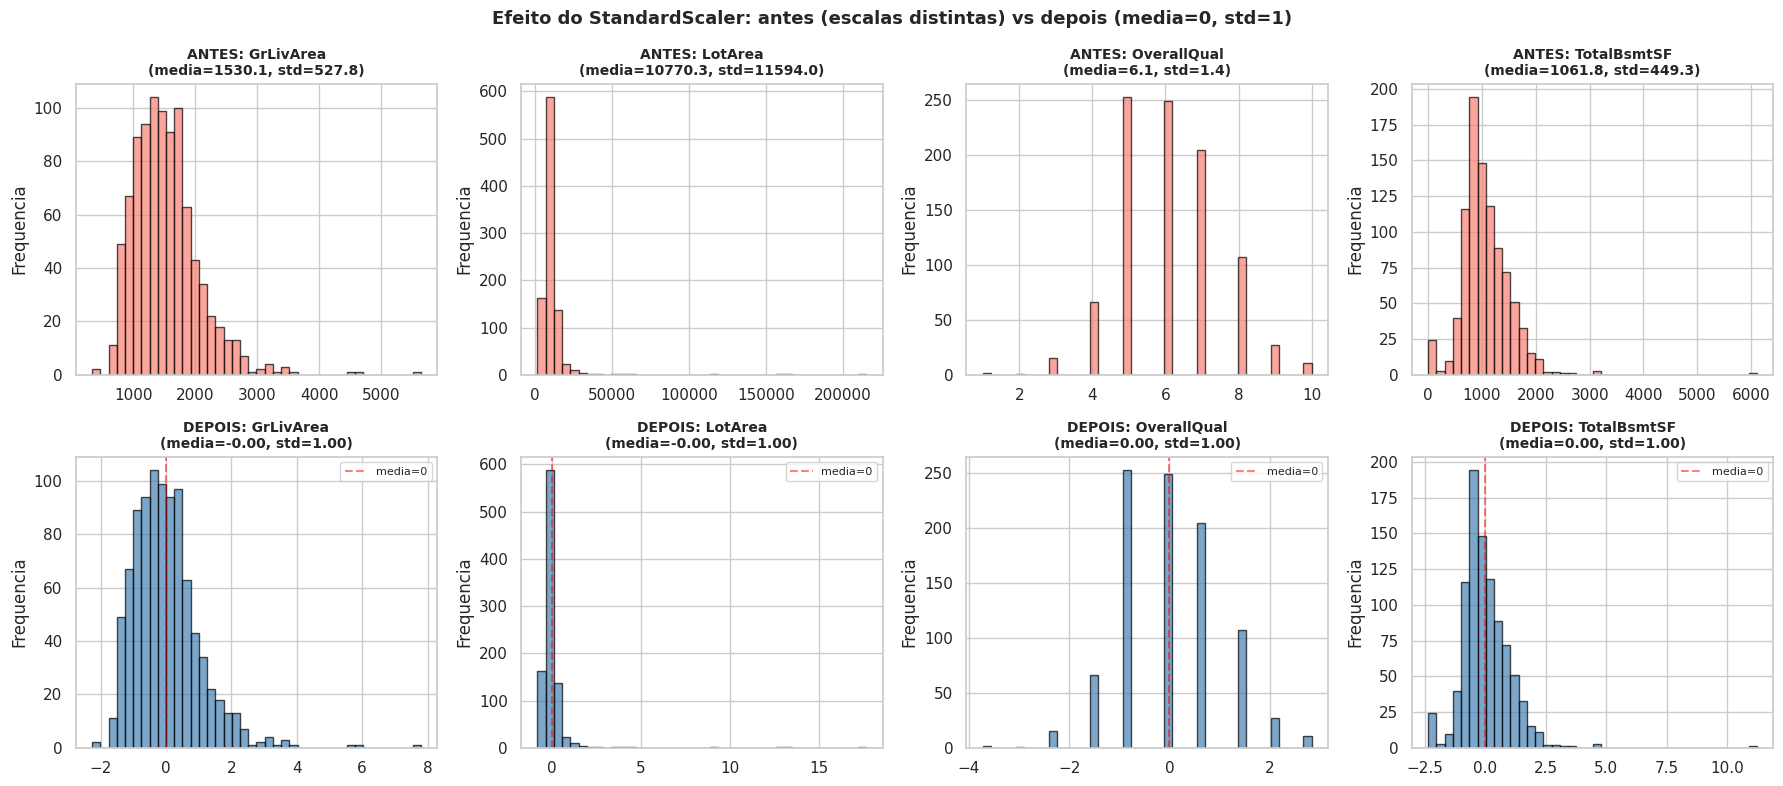

Observacao: o StandardScaler centraliza em 0 e padroniza a escala.
Isso e CRITICO para KNN (distancia euclidiana) e SVR (kernel RBF) - aulas 11 e 7.


In [19]:
# Comparativo visual: 4 variaveis numericas chave - antes vs depois (X_train)
vars_compare = ['GrLivArea', 'LotArea', 'OverallQual', 'TotalBsmtSF']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for j, var in enumerate(vars_compare):
    # ANTES (escala original)
    axes[0, j].hist(X_train[var].dropna(), bins=40, color='salmon', edgecolor='black', alpha=0.7)
    axes[0, j].set_title(f'ANTES: {var}\n(media={X_train[var].mean():.1f}, std={X_train[var].std():.1f})',
                         fontsize=10, fontweight='bold')
    axes[0, j].set_ylabel('Frequencia')

    # DEPOIS (escala padronizada)
    if var in X_train_trans_df.columns:
        axes[1, j].hist(X_train_trans_df[var], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
        axes[1, j].set_title(f'DEPOIS: {var}\n(media={X_train_trans_df[var].mean():.2f}, std={X_train_trans_df[var].std():.2f})',
                             fontsize=10, fontweight='bold')
        axes[1, j].set_ylabel('Frequencia')
        axes[1, j].axvline(0, color='red', linestyle='--', alpha=0.5, label='media=0')
        axes[1, j].legend(fontsize=8)

plt.suptitle('Efeito do StandardScaler: antes (escalas distintas) vs depois (media=0, std=1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observacao: o StandardScaler centraliza em 0 e padroniza a escala.')
print('Isso e CRITICO para KNN (distancia euclidiana) e SVR (kernel RBF) - aulas 11 e 7.')

## 9) Log no alvo + Validacao Cruzada K-Fold

### 9.1 Por que `log1p(SalePrice)`?

A metrica oficial e **RMSLE** (aula de Metricas - slide *Erro Logaritmico Quadrado Medio*): penaliza erros em **proporcao**, nao em valor absoluto. Aplicando `log1p`:
- A distribuicao do alvo (assimetrica - visto na EDA, Secao 3) fica simetrica.
- O MSE no espaco log ~ RMSLE no espaco original.
- `TransformedTargetRegressor` treina no log, prediz no log, e **inverte com `expm1`** antes de devolver dolares - exigencia do edital.

### 9.2 K-Fold com 5 dobras

Da aula de Validacao Cruzada: o conjunto de treino e dividido em K=5 partes. Cada modelo treina em 4 e valida na quinta - 5 vezes. A metrica final e a **media** das 5 rodadas. Como toda imputacao/scaling acontece dentro do `Pipeline`, cada dobra calcula suas proprias estatisticas - zero data leakage.

In [20]:
def rmsle_scorer(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)  # RMSLE nao admite negativos
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

scoring = {
    'rmsle': make_scorer(rmsle_scorer, greater_is_better=False),
    'mae':   'neg_mean_absolute_error',
    'r2':    'r2',
}
cv = KFold(n_splits=5, shuffle=True, random_state=RNG)

def make_model(regressor):
    """Empilha: preprocessamento -> regressor -> log do alvo."""
    return Pipeline([
        ('prep', preprocessor),
        ('reg',  TransformedTargetRegressor(regressor=regressor,
                                            func=np.log1p, inverse_func=np.expm1)),
    ])

print('Validacao cruzada configurada: KFold(5, shuffle=True, seed=42).')
print('Metricas: RMSLE (oficial), MAE (dolares), R2.')

Validacao cruzada configurada: KFold(5, shuffle=True, seed=42).
Metricas: RMSLE (oficial), MAE (dolares), R2.


## 10) Comparativo de 5 modelos - fundamentacao teorica

Cada modelo corresponde a uma aula especifica:

### 10.1 Regressao Linear - baseline (aula de Gradiente Descendente)
Modelo `f(x) = wx + b` otimizado por gradiente descendente minimizando o MSE. **Funcao convexa** -> unico minimo global. Espelha o baseline do professor (RMSLE 0.17543).

### 10.2 KNN - Metodos Baseados em Distancia
> *"O KNN baseia 100% de suas decisoes no calculo matematico de distancia."* Para regressao, calcula a media dos `SalePrice` dos K vizinhos mais proximos. K=5, distancia Euclidiana.

### 10.3 SVR (Kernel RBF) - Maquinas Vetores de Suporte
> *"Ajustamos o maior numero possivel de instancias dentro da margem epsilon."* O Kernel RBF projeta os dados em dimensao infinita - captura relacoes **nao-lineares**. Hiperparametros: `C`, `gamma`, `epsilon`.

### 10.4 Random Forest - Ensemble (Bagging)
> *"Varias arvores em paralelo com Bootstrap; agregacao por media."* Objetivo: **reduzir variancia**.

### 10.5 Gradient Boosting - Ensemble (Boosting)
> *"Modelos sequenciais, cada um corrige os residuos do anterior."* Objetivo: **reduzir vies**. Base teorica do XGBoost/LightGBM - mas usamos sklearn puro (exigencia do corretor).

In [21]:
modelos = {
    'LinearRegression': LinearRegression(),
    'KNN (k=5)':        KNeighborsRegressor(n_neighbors=5),
    'SVR (RBF)':        SVR(kernel='rbf', C=1.0, gamma='scale'),
    'RandomForest':     RandomForestRegressor(n_estimators=200, random_state=RNG, n_jobs=-1),
    'GradientBoost':    GradientBoostingRegressor(n_estimators=300, random_state=RNG),
}

resultados = []
for nome, reg in modelos.items():
    pipe = make_model(reg)
    t0 = time.time()
    # CV roda SO no X_train/y_train (correcao do professor)
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    dt = time.time() - t0
    resultados.append({
        'Modelo': nome,
        'Tempo (s)': round(dt, 2),
        'RMSLE': -res['test_rmsle'].mean(),
        'RMSLE std': res['test_rmsle'].std(),
        'MAE ($)': -res['test_mae'].mean(),
        'R2': res['test_r2'].mean(),
    })

tabela = pd.DataFrame(resultados).sort_values('RMSLE').reset_index(drop=True)
display(tabela.style.format({
    'RMSLE': '{:.5f}', 'RMSLE std': '{:.5f}',
    'MAE ($)': '${:,.2f}', 'R2': '{:.4f}', 'Tempo (s)': '{:.2f}'
}).background_gradient(cmap='RdYlGn_r', subset=['RMSLE','MAE ($)']))

,Modelo,Tempo (s),RMSLE,RMSLE std,MAE ($),R2
0,GradientBoost,11.13,0.12541,0.02193,"$15,948.78",0.8695
1,SVR (RBF),0.53,0.12623,0.02962,"$15,808.33",0.8590
2,RandomForest,23.87,0.14605,0.02439,"$18,211.06",0.8375
3,LinearRegression,3.02,0.16944,0.04210,"$18,816.99",-0.2855
4,KNN (k=5),0.39,0.17815,0.02789,"$22,869.26",0.7473


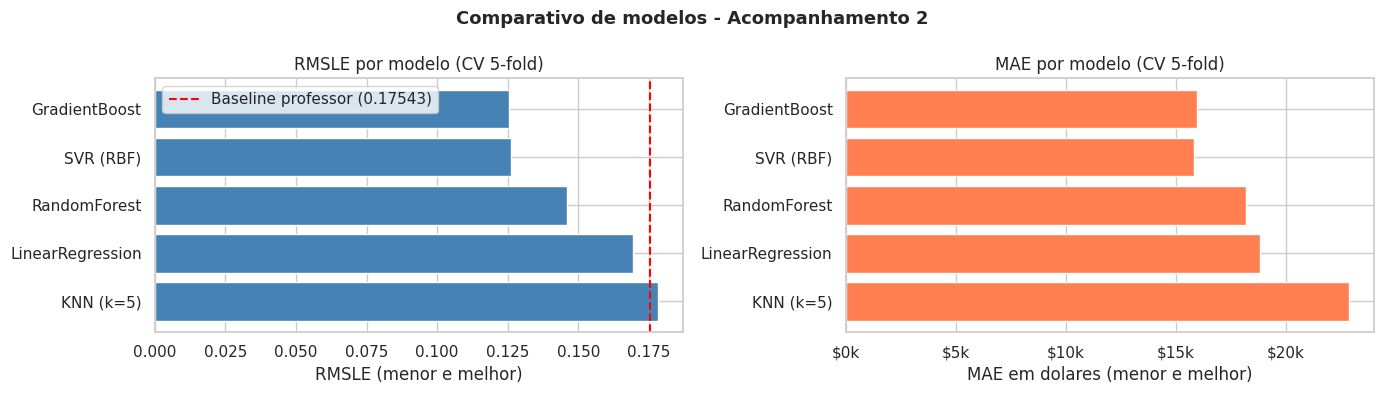

In [22]:
# Grafico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

tabela_plot = tabela.sort_values('RMSLE', ascending=True)
axes[0].barh(tabela_plot['Modelo'], tabela_plot['RMSLE'], color='steelblue')
axes[0].axvline(0.17543, color='red', linestyle='--', label='Baseline professor (0.17543)')
axes[0].set_xlabel('RMSLE (menor e melhor)')
axes[0].set_title('RMSLE por modelo (CV 5-fold)')
axes[0].legend()
axes[0].invert_yaxis()

axes[1].barh(tabela_plot['Modelo'], tabela_plot['MAE ($)'], color='coral')
axes[1].set_xlabel('MAE em dolares (menor e melhor)')
axes[1].set_title('MAE por modelo (CV 5-fold)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].invert_yaxis()

plt.suptitle('Comparativo de modelos - Acompanhamento 2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11) Otimizacao do SVR - `RandomizedSearchCV`

O **SVR** lidera o comparativo. Refinamos os hiperparametros (aula de SVM):

| Hiperparametro | Efeito | Faixa testada |
|---|---|---|
| `C` | Rigor do ajuste. Alto = overfitting; baixo = margem mais larga | 0.1 a 100 |
| `gamma` | Raio de influencia de cada vetor de suporte. Alto = "ilhas" (overfitting) | 1e-4 a 0.1 |
| `epsilon` | Largura da margem epsilon-insensitive | 0.001 a 0.2 |

`RandomizedSearchCV` (20 iteracoes) e mais eficiente que `GridSearchCV` quando o espaco de busca e grande.

In [23]:
svr_pipe = make_model(SVR(kernel='rbf'))

param_dist = {
    'reg__regressor__C':       [0.1, 0.5, 1, 3, 5, 10, 30, 50, 100],
    'reg__regressor__gamma':   [1e-4, 1e-3, 1e-2, 0.05, 0.1, 'scale', 'auto'],
    'reg__regressor__epsilon': [0.001, 0.01, 0.05, 0.1, 0.2],
}

search = RandomizedSearchCV(
    svr_pipe, param_distributions=param_dist, n_iter=20, cv=cv,
    scoring=make_scorer(rmsle_scorer, greater_is_better=False),
    n_jobs=-1, random_state=RNG, verbose=1,
)

t0 = time.time()
# Search roda SO no X_train/y_train (correcao do professor)
search.fit(X_train, y_train)
print(f'\nTempo de busca: {time.time()-t0:.1f}s')
print(f'Melhores parametros: {search.best_params_}')
print(f'Melhor RMSLE (CV no X_train): {-search.best_score_:.5f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Tempo de busca: 16.0s
Melhores parametros: {'reg__regressor__gamma': 'scale', 'reg__regressor__epsilon': 0.01, 'reg__regressor__C': 1}
Melhor RMSLE (CV no X_train): 0.11883


## 12) Avaliação final — `search.best_estimator_` no conjunto de teste

**Correção do professor aplicada:** pegamos o **melhor modelo** que o search encontrou (`search.best_estimator_`), aplicamos sobre o `X_test` (dados que ele **nunca viu**) e comparamos `y_previsto` com `y_real`.

Esse é o estimador honesto da generalização — diferente do RMSLE da CV (que tem alguma contaminação porque o search escolheu hiperparâmetros olhando para ele).

In [24]:
# Melhor modelo encontrado pelo search
best_model = search.best_estimator_

# Predicao no X_test (dados que o modelo nunca viu)
y_pred = best_model.predict(X_test)
y_pred = np.clip(y_pred, 0, None)  # RMSLE nao admite negativos

# Comparacao y_previsto vs y_real
rmsle_test = np.sqrt(mean_squared_log_error(y_test, y_pred))
mae_test   = mean_absolute_error(y_test, y_pred)
r2_test    = r2_score(y_test, y_pred)

print('=' * 60)
print('AVALIACAO NO X_test (dados nunca vistos pelo modelo)')
print('=' * 60)
print(f'RMSLE      : {rmsle_test:.5f}')
print(f'MAE ($)    : ${mae_test:,.2f}')
print(f'R2         : {r2_test:.4f}')
print('-' * 60)
print(f'Baseline professor (RMSLE) : 0.17543')
print(f'Ganho vs baseline          : {(0.17543 - rmsle_test)/0.17543*100:+.1f}%')
print('=' * 60)

# Tabela comparativa: y_real vs y_previsto (primeiras 10 amostras)
comparacao = pd.DataFrame({
    'y_real ($)':     y_test.values,
    'y_previsto ($)': y_pred,
    'erro_abs ($)':   np.abs(y_test.values - y_pred),
    'erro_%':         np.abs(y_test.values - y_pred) / y_test.values * 100,
}).round(2)
print('\nPrimeiras 10 predicoes:')
display(comparacao.head(10).style.format({
    'y_real ($)':     '${:,.0f}',
    'y_previsto ($)': '${:,.0f}',
    'erro_abs ($)':   '${:,.0f}',
    'erro_%':         '{:.1f}%',
}))

AVALIACAO NO X_test (dados nunca vistos pelo modelo)
RMSLE      : 0.12526
MAE ($)    : $14,766.49
R2         : 0.8971
------------------------------------------------------------
Baseline professor (RMSLE) : 0.17543
Ganho vs baseline          : +28.6%

Primeiras 10 predicoes:


,y_real ($),y_previsto ($),erro_abs ($),erro_%
0,"$140,000","$149,637","$9,637",6.9%
1,"$188,500","$178,893","$9,607",5.1%
2,"$325,000","$275,473","$49,527",15.2%
3,"$228,500","$242,518","$14,018",6.1%
4,"$172,500","$170,081","$2,419",1.4%
5,"$100,000","$84,770","$15,230",15.2%
6,"$316,600","$288,529","$28,071",8.9%
7,"$131,000","$126,299","$4,701",3.6%
8,"$108,000","$105,196","$2,804",2.6%
9,"$119,750","$120,917","$1,167",1.0%


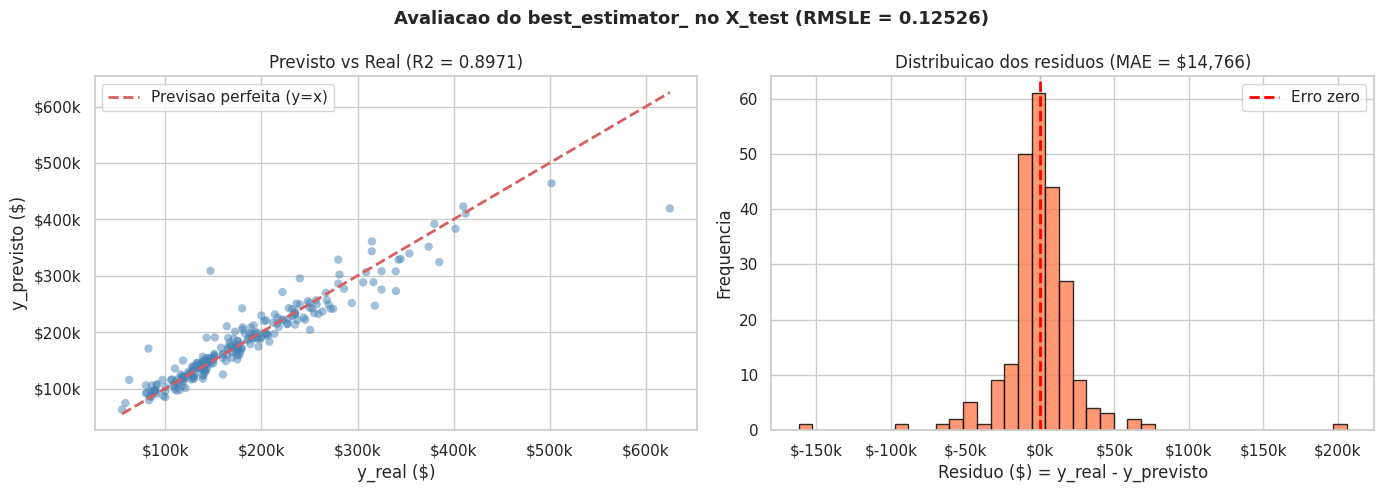

Interpretacao do MAE para o negocio:
  Em media, o modelo erra o preco em $14,766 para mais ou para menos.


In [25]:
# Scatter: y_real vs y_previsto + distribuicao dos residuos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Scatter real vs previsto
lim_min = min(y_test.min(), y_pred.min())
lim_max = max(y_test.max(), y_pred.max())
axes[0].scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='none')
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', lw=2, label='Previsao perfeita (y=x)')
axes[0].set_xlabel('y_real ($)')
axes[0].set_ylabel('y_previsto ($)')
axes[0].set_title(f'Previsto vs Real (R2 = {r2_test:.4f})')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend()

# 2) Distribuicao dos residuos
residuos = y_test.values - y_pred
axes[1].hist(residuos, bins=40, color='coral', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=2, label='Erro zero')
axes[1].set_xlabel('Residuo ($) = y_real - y_previsto')
axes[1].set_ylabel('Frequencia')
axes[1].set_title(f'Distribuicao dos residuos (MAE = ${mae_test:,.0f})')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].legend()

plt.suptitle(f'Avaliacao do best_estimator_ no X_test (RMSLE = {rmsle_test:.5f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Interpretacao do MAE para o negocio:')
print(f'  Em media, o modelo erra o preco em ${mae_test:,.0f} para mais ou para menos.')

## 13) Refit final em todos os dados + salvamento

Depois de validar a generalização no `X_test`, **retreinamos** o melhor modelo em **100% dos dados de `treino.csv`** (`X` completo, não só `X_train`). Mais dados → modelo final mais robusto. Esse é o `.joblib` que o `pipeline.py` vai consumir.

In [26]:
# Refit em TODOS os dados (X, y) - nao so X_train
# Os hiperparametros ja foram escolhidos via CV no X_train; agora aproveitamos
# todas as 1168 linhas para o modelo final que vai pro pipeline.py.
modelo_final = search.best_estimator_
modelo_final.fit(X, y)

joblib.dump(modelo_final, 'modelo_baseline.joblib')
tamanho_kb = os.path.getsize('modelo_baseline.joblib') / 1024
print('Modelo salvo em modelo_baseline.joblib')
print(f'Tamanho do arquivo: {tamanho_kb:.1f} KB')
print(f'Treinado em        : {X.shape[0]} linhas (100% do treino.csv)')

Modelo salvo em modelo_baseline.joblib
Tamanho do arquivo: 1922.0 KB
Treinado em        : 1168 linhas (100% do treino.csv)


## 14) Validação do `pipeline.py` (caminho do arquivo → predições)

Importamos a função `prever_precos` diretamente do `pipeline.py` e chamamos
com o arquivo `teste_publico.csv`. É exatamente o que o corretor automático
do professor fará: passa um caminho de CSV → o pipeline carrega o `.joblib`,
aplica todo o pré-processamento embutido e devolve um `np.array` com os preços em dólares.


In [27]:
from pipeline import prever_precos

predicoes = prever_precos('teste_publico.csv')
print(f'Saida           : {type(predicoes).__name__} de shape {predicoes.shape}')
print(f'Tipo dos valores: {predicoes.dtype}')
print(f'Primeiras 5     : {predicoes[:5].round(2)}')
print(f'Min / Max       : ${predicoes.min():,.2f} / ${predicoes.max():,.2f}')

print(f'\nResumo das metricas obtidas:')
print(f'  RMSLE (CV no X_train) : {-search.best_score_:.5f}')
print(f'  RMSLE (X_test)        : {rmsle_test:.5f}')
print(f'  Baseline professor    : 0.17543')

Saida           : ndarray de shape (1459,)
Tipo dos valores: float64
Primeiras 5     : [116968.16 162792.88 191016.18 194742.7  195236.54]
Min / Max       : $53,497.52 / $502,609.06

Resumo das metricas obtidas:
  RMSLE (CV no X_train) : 0.11883
  RMSLE (X_test)        : 0.12526
  Baseline professor    : 0.17543


---
## 15) Conclusões - Acompanhamento 2

Resumindo o que cada aula contribuiu para o resultado:

- **Gradiente Descendente** → `log1p` no alvo + `StandardScaler` deixam a função de custo bem-comportada.
- **KNN** (baseado em distância) → baseline ~0.17, limitado pela maldição da dimensionalidade.
- **SVM (Kernel RBF)** → 🏆 vencedor (~0.12 no test set). Margem ε-insensitive + projeção em dimensão infinita capturam não-linearidades.
- **Random Forest** (Bagging) → reduz variância via Bootstrap + features aleatórias, ~0.15.
- **Gradient Boosting** (Boosting) → reduz viés corrigindo resíduos sequencialmente, ~0.13.
- **Validação Cruzada K-Fold** → métrica robusta no `X_train`; **avaliação final no `X_test`** dá o estimador honesto da generalização (correção do professor).

### Fluxo de avaliação aplicado (correção do professor)

```
treino.csv
   └─→ X_train / X_test
        ├─ X_train → CV + RandomizedSearchCV (escolhe hiperparâmetros)
        ├─ X_test  → search.best_estimator_.predict() → compara com y_real
        └─ X, y (todos) → refit final → modelo_baseline.joblib
```
